[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part5-commercial-analytics/sec5.1_price_elasticity.ipynb)

# Price Elasticity & Margin Optimization — Scanner Data

This notebook accompanies **Chapter 5.1** of *Marketing Science in Python*.
We estimate price elasticity from grocery scanner data using a power-law model,
apply a two-pass robust estimation procedure, and then find the price that
maximizes **contribution margin**.

**Learning objectives**

1. Compute effective price from revenue / units and run data-quality checks.
2. Fit a constant-elasticity (power-law) demand model with two-pass outlier removal.
3. Interpret elasticity, R², and confidence intervals.
4. Compare elasticity across **product roles** (sub-commodity within a category).
5. Optimize contribution margin = (Price − Cost) × Q(Price).
6. Build a price-sensitivity table for stakeholder communication.

**Dataset**: Dunnhumby "The Complete Journey" (Kaggle, public).
Transaction-level grocery data from 2,500 households across 582 stores
over 102 weeks. We focus on the **Fluid Milk Products** category, which
offers 40–60 distinct effective prices per top product — producing
far richer elasticity curves than state-controlled pricing datasets.

In [1]:
# Colab: install the Kaggle download helper used as a data-loading fallback.
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize_scalar
from scipy.stats import t as t_dist

In [3]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo root marker, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401
from msbook.paths import chapter_images

# In a Jupyter kernel `display` is a builtin; running this .py directly it is
# not, so fall back to print (matches the sec5.2 companion).
try:
    display  # noqa: F821
except NameError:
    display = print

# ── All tuneable parameters in one place ────────────────────────────────────────
CONFIG = {
    "data_path": "../../data/raw/Dunnhumby_kaggle/",
    "kaggle_dataset": "frtgnn/dunnhumby-the-complete-journey",
    "category_filter": "FLUID MILK PRODUCTS",
    "top_n_items": 8,
    # Data-quality thresholds (Chapter 5.1 pseudocode)
    "min_distinct_prices": 3,
    "max_mode_share": 0.70,
    "min_weeks": 26,
    "min_price_range": 0.10,
    # Two-pass outlier bounds
    "outlier_ratio_low": 0.3,
    "outlier_ratio_high": 3.0,
    # Confidence & interpretation
    "confidence_level": 0.95,
    "r2_threshold": 0.4,
    "elasticity_plausible_range": (-5.0, -0.5),
    # Assumed cost ratio (no cost column in Dunnhumby data)
    "assumed_cost_ratio": 0.55,
}

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Single canonical figure dir; resolved via msbook so this works from any cwd.
_FIG_DIR = chapter_images(part="5", chapter="sec5.1")


def savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)

## 1. Why Elasticity Matters

Price elasticity of demand measures how sensitive quantity sold is to a
change in price:

$$
\varepsilon = \frac{\%\,\Delta\,\text{Quantity}}{\%\,\Delta\,\text{Price}}
$$

- **Elastic** ($|\varepsilon| > 1$): a 10 % price hike loses *more* than 10 % of
  units — revenue falls.
- **Inelastic** ($|\varepsilon| < 1$): volume barely moves — the brand has
  pricing power.

But **revenue alone is rarely the objective.** A price increase that shrinks
revenue can still *grow* contribution margin if the per-unit margin gain
outweighs the volume loss. Being explicit about which objective you are
optimizing — revenue, margin, traffic — is the core discipline of this chapter,
and when reliable cost data exists, margin is usually the one to optimize.

## 2. Dataset — Dunnhumby "The Complete Journey"

The Dunnhumby dataset captures transaction-level grocery purchases from
2,500 households across 582 stores over 102 weeks. We focus on **Fluid
Milk Products** — a high-frequency staple category with rich price
variation from promotions.

**transaction_data.csv** — 135 MB, one row per item per basket:

| Column | Meaning |
|--------|---------|
| `PRODUCT_ID` | Links to the product table |
| `QUANTITY` | Number of units purchased |
| `SALES_VALUE` | Dollar amount paid (after store discounts) |
| `RETAIL_DISC` | Store discount amount (negative = discount applied) |
| `STORE_ID` | Store identifier |
| `WEEK_NO` | Week number (1–102) |

**product.csv** — product metadata:

| Column | Meaning |
|--------|---------|
| `PRODUCT_ID` | Join key |
| `COMMODITY_DESC` | Category (we filter to `FLUID MILK PRODUCTS`) |
| `SUB_COMMODITY_DESC` | Sub-category (e.g., SKIM MILK, WHOLE MILK) |
| `BRAND` | `National` or `Private` (store brand) |
| `CURR_SIZE_OF_PRODUCT` | Pack size string |

We compute **effective price** = `SALES_VALUE / QUANTITY`, which naturally
accounts for promotional pricing. About 50 % of rows carry a retail
discount, giving us genuine price variation across weeks and stores.

In [4]:
def load_dunnhumby_data(config):
    """Load Dunnhumby transaction + product data, filter to target category.

    Joins transaction_data.csv with product.csv, filters to the target
    commodity, and computes effective price = SALES_VALUE / QUANTITY.
    """
    import pathlib

    data_dir = pathlib.Path(config["data_path"])
    if not (data_dir / "transaction_data.csv").exists():
        # Fallback: download via kagglehub (Colab / first-time readers)
        try:
            import kagglehub
            data_dir = pathlib.Path(kagglehub.dataset_download(config["kaggle_dataset"]))
            print(f"Downloaded Dunnhumby to {data_dir}")
        except Exception as e:
            raise FileNotFoundError(
                f"Dunnhumby data not found at {data_dir}. Download from Kaggle: "
                f"https://www.kaggle.com/datasets/{config['kaggle_dataset']}\n"
                f"Error: {e}"
            )

    # Read product metadata
    products = pd.read_csv(data_dir / "product.csv")
    target_ids = products[
        products["COMMODITY_DESC"] == config["category_filter"]
    ]["PRODUCT_ID"].unique()
    print(f"Product catalog: {len(target_ids)} products in '{config['category_filter']}'")

    # Read transactions
    txn = pd.read_csv(data_dir / "transaction_data.csv")

    # Filter to target category
    txn = txn[txn["PRODUCT_ID"].isin(target_ids)].copy()

    # Keep only positive quantity and sales
    txn = txn[(txn["QUANTITY"] > 0) & (txn["SALES_VALUE"] > 0)].copy()

    # Join product metadata
    txn = txn.merge(
        products[["PRODUCT_ID", "BRAND", "SUB_COMMODITY_DESC", "CURR_SIZE_OF_PRODUCT"]],
        on="PRODUCT_ID", how="left",
    )

    # Compute effective price
    txn["effective_price"] = (txn["SALES_VALUE"] / txn["QUANTITY"]).round(2)

    print(f"Loaded {len(txn):,} transactions  |  "
          f"weeks {txn['WEEK_NO'].min()}–{txn['WEEK_NO'].max()}  |  "
          f"{txn['PRODUCT_ID'].nunique()} products  |  "
          f"{txn['STORE_ID'].nunique()} stores")
    return txn


raw = load_dunnhumby_data(CONFIG)
raw.head(3)

Product catalog: 455 products in 'FLUID MILK PRODUCTS'


Loaded 85,494 transactions  |  weeks 1–102  |  455 products  |  329 stores


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,BRAND,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,effective_price
0,1172,26985025264,1,1106523,1,1.50,396,0.00,946,1,0.00,0.00,Private,FLUID MILK WHITE ONLY,1 GA,1.50
1,1060,26985040735,1,1081189,1,1.16,315,-0.13,1251,1,0.00,0.00,Private,FLUID MILK WHITE ONLY,1 QT,1.16
2,2305,26996870743,2,1028891,1,3.19,414,0.00,1300,1,0.00,0.00,National,REFRIGERATED COFFEE CREAMERS,32 OZ,3.19


In [5]:
def aggregate_weekly(df):
    """Aggregate transactions to (product x week) level.

    Sums quantity and sales across all stores and households for each
    product-week, then recomputes effective price from the totals.
    Builds a human-readable item label from product metadata.
    """
    df = df.copy()
    # Build base label: SUB_COMMODITY + BRAND + SIZE
    df["_base_label"] = (
        df["SUB_COMMODITY_DESC"].str.title() + " — "
        + df["BRAND"].str.title() + " "
        + df["CURR_SIZE_OF_PRODUCT"].fillna("").str.strip()
    )

    agg = (
        df.groupby(["PRODUCT_ID", "_base_label", "BRAND", "WEEK_NO"])
        .agg(
            units=("QUANTITY", "sum"),
            revenue=("SALES_VALUE", "sum"),
        )
        .reset_index()
    )
    agg["effective_price"] = (agg["revenue"] / agg["units"]).round(2)

    # Disambiguate labels that map to multiple PRODUCT_IDs
    pid_label = agg.groupby("PRODUCT_ID")["_base_label"].first()
    dup_mask = pid_label.duplicated(keep=False)
    dup_labels = pid_label[dup_mask]
    relabel = {}
    for base, group in dup_labels.groupby(dup_labels):
        for i, pid in enumerate(sorted(group.index), 1):
            relabel[pid] = f"{base} #{i}"
    agg["item_label"] = agg["PRODUCT_ID"].map(relabel).fillna(agg["_base_label"])
    agg.drop(columns=["_base_label"], inplace=True)

    return agg


weekly = aggregate_weekly(raw)
print(f"Weekly dataset: {len(weekly):,} rows  |  "
      f"{weekly['PRODUCT_ID'].nunique()} products  |  "
      f"{weekly['item_label'].nunique()} unique labels")
weekly.head()

Weekly dataset: 8,814 rows  |  455 products  |  455 unique labels


,PRODUCT_ID,BRAND,WEEK_NO,units,revenue,effective_price,item_label
0,28272,Private,7,1,1.09,1.09,Fluid Milk White Only — Private 1 QT #1
1,28272,Private,9,1,1.09,1.09,Fluid Milk White Only — Private 1 QT #1
2,28272,Private,26,1,1.09,1.09,Fluid Milk White Only — Private 1 QT #1
3,28272,Private,33,1,1.19,1.19,Fluid Milk White Only — Private 1 QT #1
4,28272,Private,35,1,1.19,1.19,Fluid Milk White Only — Private 1 QT #1


In [6]:
def select_top_items(agg, n):
    """Keep only the top-n items by total units sold."""
    top = agg.groupby("PRODUCT_ID")["units"].sum().nlargest(n).index
    return agg[agg["PRODUCT_ID"].isin(top)].copy()


weekly = select_top_items(weekly, CONFIG["top_n_items"])

summary = (
    weekly.groupby("item_label")
    .agg(
        weeks=("WEEK_NO", "nunique"),
        total_units=("units", "sum"),
        distinct_prices=("effective_price", "nunique"),
        avg_price=("effective_price", "mean"),
    )
    .sort_values("total_units", ascending=False)
)
summary

,weeks,total_units,distinct_prices,avg_price
item_label,,,,
Fluid Milk White Only — Private #13,102,21758,49,1.48
Fluid Milk White Only — Private 1 GA #9,102,16972,41,2.47
Fluid Milk White Only — Private #16,101,12318,59,1.48
Fluid Milk White Only — Private 1 GA #11,102,11497,41,2.46
Chocolate Milk — Private #4,102,7260,52,1.47
Fluid Milk White Only — Private #12,101,6690,49,1.48
Fluid Milk White Only — Private #15,101,6359,51,1.48
Fluid Milk White Only — Private 1 GA #12,102,5495,43,2.47


## 3. Data Quality Checks

Before fitting any model, we validate that each item has enough price
variation.  Four criteria (from Chapter 5.1):

1. **Distinct prices** $\geq 3$ — need enough points to fit a curve.
2. **Mode share** $\leq 70\%$ — no single price dominates.
3. **Observation count** $\geq 26$ weeks — enough data for seasonality.
4. **Price range** $\geq 10\%$ — max/min spread is meaningful.

With 40–60 distinct prices per product and promotional discounts in
half of all transactions, we expect all top items to pass easily.

In [7]:
def check_data_quality(item_df, config):
    """Run the four pre-modeling quality checks on one item's weekly data."""
    price = item_df["effective_price"]
    checks = {
        "distinct_prices": int(price.nunique()) >= config["min_distinct_prices"],
        "price_diversity":  price.value_counts(normalize=True).iloc[0] <= config["max_mode_share"],
        "min_length":       len(item_df) >= config["min_weeks"],
        "price_range":      (price.max() / price.min() - 1) >= config["min_price_range"],
    }
    checks["pass_all"] = all(checks.values())
    return checks

In [8]:
# Run checks on every item
quality = {}
for label, grp in weekly.groupby("item_label"):
    quality[label] = check_data_quality(grp, CONFIG)

quality_df = pd.DataFrame(quality).T
print("Quality-check results:")
display(quality_df)

# Keep items passing all checks
passing_items = quality_df[quality_df["pass_all"]].index.tolist()
weekly = weekly[weekly["item_label"].isin(passing_items)].copy()
print(f"\n{len(passing_items)} items pass all checks")

Quality-check results:


,distinct_prices,price_diversity,min_length,price_range,pass_all
Chocolate Milk — Private #4,True,True,True,True,True
Fluid Milk White Only — Private #12,True,True,True,True,True
Fluid Milk White Only — Private #13,True,True,True,True,True
Fluid Milk White Only — Private #15,True,True,True,True,True
Fluid Milk White Only — Private #16,True,True,True,True,True
Fluid Milk White Only — Private 1 GA #11,True,True,True,True,True
Fluid Milk White Only — Private 1 GA #12,True,True,True,True,True
Fluid Milk White Only — Private 1 GA #9,True,True,True,True,True



8 items pass all checks


## 4. The Power-Law Demand Model

The constant-elasticity model:

$$
Q = b_0 \times P^{\,b_1}
$$

In log-log space this is linear ($\log Q = \log b_0 + b_1 \log P$),
so $b_1$ is the elasticity: a 1 % price change produces a $b_1$ %
quantity change, regardless of the price level.

We fit in the *original* (non-log) space via `scipy.optimize.curve_fit`
to avoid retransformation bias.

In [9]:
def power_model(price, b0, b1):
    """Q = b0 * Price^b1"""
    return b0 * np.power(price, b1)


def fit_elasticity_two_pass(prices, units, config):
    """Two-pass power-law fit with outlier removal.

    Returns a dict with fitted parameters, R², counts, and clean data.
    """
    prices = np.asarray(prices, dtype=float)
    units = np.asarray(units, dtype=float)
    p0 = [units.mean(), -1.5]

    # Pass 1 — all data
    popt1, _ = curve_fit(power_model, prices, units, p0=p0, maxfev=10_000)

    # Flag outliers by actual/predicted ratio
    predicted = power_model(prices, *popt1)
    ratio = units / predicted
    mask = (ratio > config["outlier_ratio_low"]) & (ratio < config["outlier_ratio_high"])

    # Pass 2 — clean data
    popt2, pcov2 = curve_fit(
        power_model, prices[mask], units[mask], p0=popt1, maxfev=10_000,
    )

    # R²
    residuals = units[mask] - power_model(prices[mask], *popt2)
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((units[mask] - units[mask].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    return {
        "b0": popt2[0], "b1": popt2[1], "pcov": pcov2,
        "r2": r2, "n_obs": int(mask.sum()), "n_outliers": int((~mask).sum()),
        "mask": mask, "prices_clean": prices[mask], "units_clean": units[mask],
    }


def compute_confidence_band(price_grid, result, confidence=0.95):
    """Delta-method confidence band on the fitted curve."""
    b0, b1, pcov = result["b0"], result["b1"], result["pcov"]
    t_val = t_dist.ppf((1 + confidence) / 2, result["n_obs"] - 2)
    y = power_model(price_grid, b0, b1)
    # Jacobian: [dy/db0, dy/db1] = [y/b0, y*ln(price)]
    J = np.column_stack([y / b0, y * np.log(price_grid)])
    var_y = np.sum(J @ pcov * J, axis=1)  # diag(J @ pcov @ J.T)
    delta = t_val * np.sqrt(np.maximum(var_y, 0))
    return y - delta, y + delta

## 5. Fitting Elasticity — Two-Pass Estimation

Promotional spikes and stockouts create outliers far from the regular
demand curve.  A two-pass procedure:

1. **Pass 1** — fit on all data.
2. **Flag outliers** — actual / predicted ratio outside (0.3, 3.0).
3. **Pass 2** — refit on clean data for a more robust elasticity estimate.

In [10]:
# Fit elasticity for every passing item
results = {}
for label, grp in weekly.groupby("item_label"):
    try:
        res = fit_elasticity_two_pass(
            grp["effective_price"].values,
            grp["units"].values,
            CONFIG,
        )
        res["avg_price"] = grp["effective_price"].mean()
        # No cost column — assume cost = 55 % of average price
        res["avg_cost"] = res["avg_price"] * CONFIG["assumed_cost_ratio"]
        res["brand"] = grp["BRAND"].iloc[0]
        results[label] = res
    except RuntimeError as e:
        print(f"  Curve-fit failed for {label}: {e}")

# Summary table
rows = []
for label, r in results.items():
    rows.append({
        "Item": label,
        "Brand": r["brand"],
        "Elasticity (b1)": r["b1"],
        "Scale (b0)": r["b0"],
        "R\u00b2": r["r2"],
        "Obs (clean)": r["n_obs"],
        "Outliers removed": r["n_outliers"],
    })

results_df = pd.DataFrame(rows).set_index("Item").sort_values("R\u00b2", ascending=False)
results_df

,Brand,Elasticity (b1),Scale (b0),R²,Obs (clean),Outliers removed
Item,,,,,,
Fluid Milk White Only — Private #16,Private,-3.73,336.10,0.92,95,6
Fluid Milk White Only — Private #13,Private,-3.57,598.93,0.90,93,9
Chocolate Milk — Private #4,Private,-3.92,205.59,0.87,94,8
Fluid Milk White Only — Private #12,Private,-2.98,159.29,0.80,96,5
Fluid Milk White Only — Private #15,Private,-2.63,137.41,0.79,96,5
Fluid Milk White Only — Private 1 GA #9,Private,-1.80,858.94,0.31,96,6
Fluid Milk White Only — Private 1 GA #11,Private,-1.33,382.21,0.23,97,5
Fluid Milk White Only — Private 1 GA #12,Private,-1.19,164.77,0.15,96,6


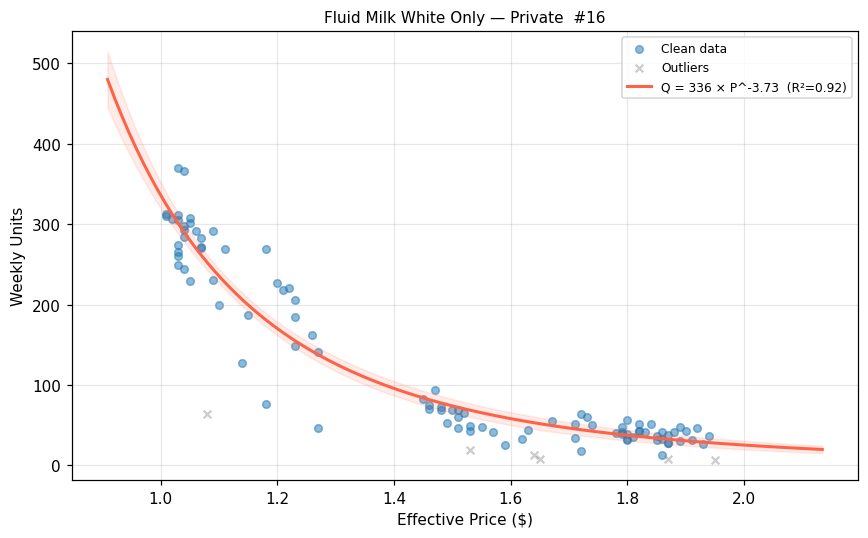

In [11]:
def plot_elasticity(label, grp, result, config, ax=None):
    """Scatter + fitted curve + confidence band for one item."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    prices = grp["effective_price"].values
    units = grp["units"].values
    mask = result["mask"]

    # Scatter: clean vs outlier
    ax.scatter(prices[mask], units[mask], alpha=0.5, s=25, label="Clean data")
    if (~mask).any():
        ax.scatter(prices[~mask], units[~mask], alpha=0.4, s=25,
                   color="grey", marker="x", label="Outliers")

    # Fitted curve + CI
    lo, hi = prices[mask].min() * 0.9, prices[mask].max() * 1.1
    grid = np.linspace(lo, hi, 200)
    fitted = power_model(grid, result["b0"], result["b1"])
    lower, upper = compute_confidence_band(grid, result, config["confidence_level"])
    ax.plot(grid, fitted, color="tomato", linewidth=2,
            label=f"Q = {result['b0']:.0f} \u00d7 P^{result['b1']:.2f}  (R\u00b2={result['r2']:.2f})")
    ax.fill_between(grid, lower, upper, color="tomato", alpha=0.12)

    ax.set_xlabel("Effective Price ($)")
    ax.set_ylabel("Weekly Units")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    return ax


# Deep-dive: pick the item with the best R²
best = results_df.index[0]
grp = weekly[weekly["item_label"] == best]
fig, ax = plt.subplots(figsize=(8, 5))
plot_elasticity(best, grp, results[best], CONFIG, ax=ax)
plt.tight_layout()
savefig(fig, "elasticity_deep_dive.png")
plt.show()

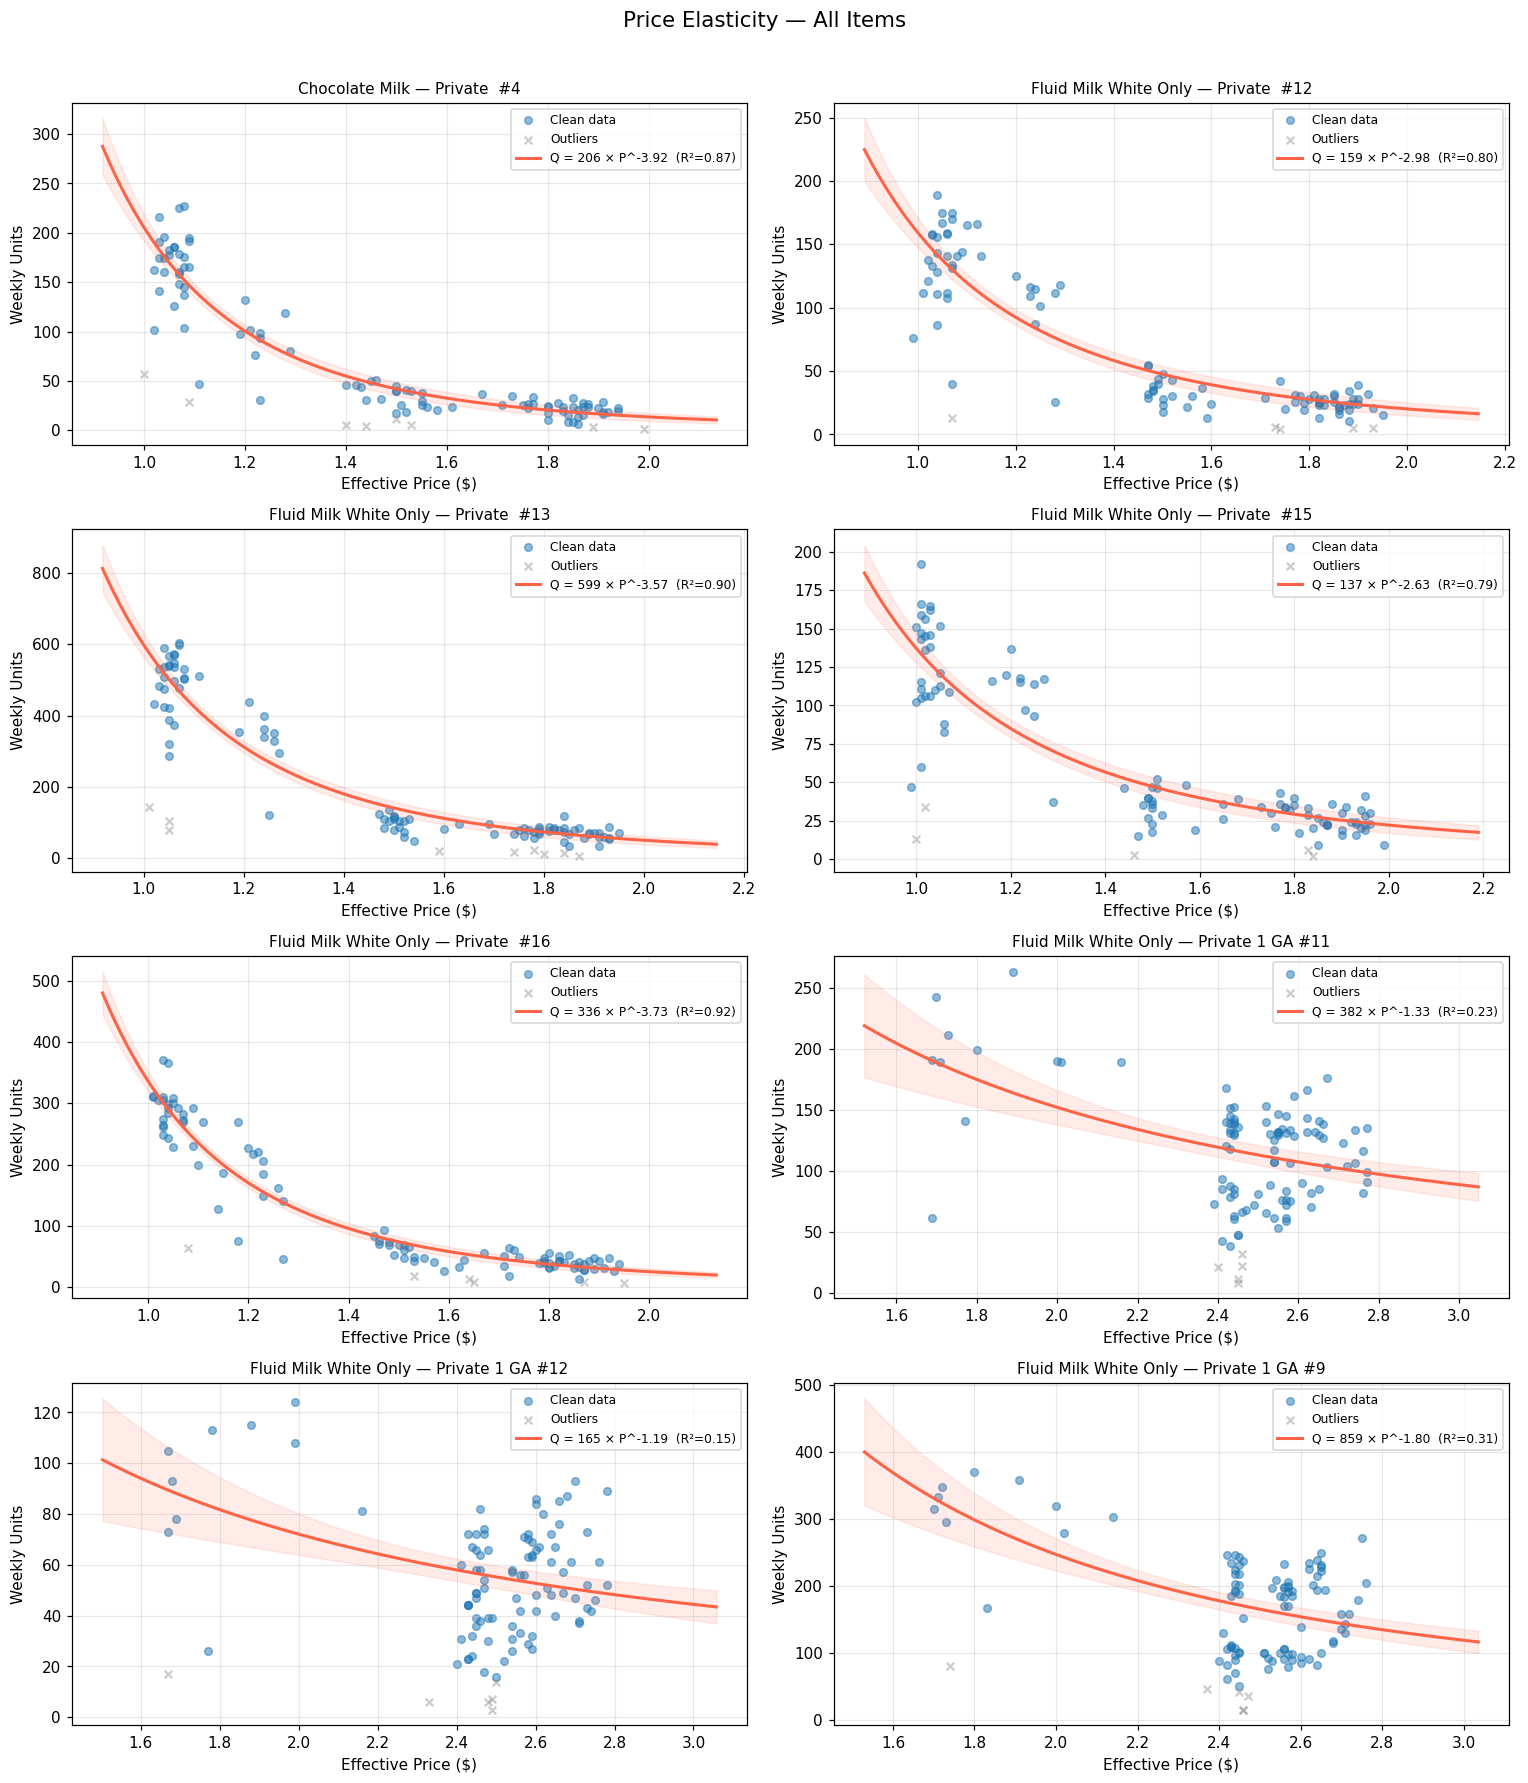

In [12]:
n_items = len(results)
ncols = 2
nrows = (n_items + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for idx, (label, res) in enumerate(results.items()):
    grp = weekly[weekly["item_label"] == label]
    plot_elasticity(label, grp, res, CONFIG, ax=axes[idx])

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Price Elasticity \u2014 All Items", fontsize=14, y=1.01)
fig.tight_layout()
savefig(fig, "elasticity_grid.png")
plt.show()

## 6. Interpreting the Results

| Condition | Verdict |
|-----------|---------|
| R² > 0.4, b₁ in (−5, −0.5), sufficient data | **Usable** for pricing decisions |
| R² > 0.4 but b₁ outside plausible range | **Investigate** data issues first |
| R² < 0.4 or wide confidence intervals | **Directional only** — don’t set prices on this |

In [13]:
def classify_result(result, config):
    """Classify an elasticity estimate as Usable / Investigate / Directional."""
    b1 = result["b1"]
    r2 = result["r2"]
    lo, hi = config["elasticity_plausible_range"]
    if r2 > config["r2_threshold"] and lo <= b1 <= hi:
        return "Usable"
    elif r2 > config["r2_threshold"]:
        return "Investigate"
    else:
        return "Directional only"


# Apply classification
for label, res in results.items():
    res["verdict"] = classify_result(res, CONFIG)

verdict_df = pd.DataFrame([
    {"Item": k, "Brand": v["brand"], "Elasticity": v["b1"],
     "R\u00b2": v["r2"], "Verdict": v["verdict"]}
    for k, v in results.items()
]).set_index("Item")
verdict_df

,Brand,Elasticity,R²,Verdict
Item,,,,
Chocolate Milk — Private #4,Private,-3.92,0.87,Usable
Fluid Milk White Only — Private #12,Private,-2.98,0.80,Usable
Fluid Milk White Only — Private #13,Private,-3.57,0.90,Usable
Fluid Milk White Only — Private #15,Private,-2.63,0.79,Usable
Fluid Milk White Only — Private #16,Private,-3.73,0.92,Usable
Fluid Milk White Only — Private 1 GA #11,Private,-1.33,0.23,Directional only
Fluid Milk White Only — Private 1 GA #12,Private,-1.19,0.15,Directional only
Fluid Milk White Only — Private 1 GA #9,Private,-1.80,0.31,Directional only


## 7. Elasticity Varies by Product Role

A single category can contain products that play very different shopper
roles. In `FLUID MILK PRODUCTS`, a gallon of white milk, a single-serve
chocolate milk, and a quart of coffee creamer are not interchangeable
pricing decisions — shoppers buy them for different occasions and compare
them against different alternatives.

So instead of one category-level number, we estimate elasticity **per SKU**
(SKU × week, two-pass), keep only SKUs that pass the data-quality checks,
and then aggregate into comparable **product roles** (`SUB_COMMODITY_DESC`)
with a units-weighted mean. The goal is not to create as many segments as
possible; it is to avoid averaging together products whose price response
should be different.

(Brand — National vs Private — is a weaker split for this dataset: in
Fluid Milk it confounds brand with product mix and size, so product role is
the more honest teaching cut.)

,product_role,n_sku,elasticity
0,Chocolate Milk,8.00,-3.59
1,Fluid Milk White Only,22.00,-2.51
2,Miscellaneous Milk,11.00,-1.60
3,Refrigerated Coffee Creamers,34.00,-1.05
4,Buttermilk,4.00,-0.98


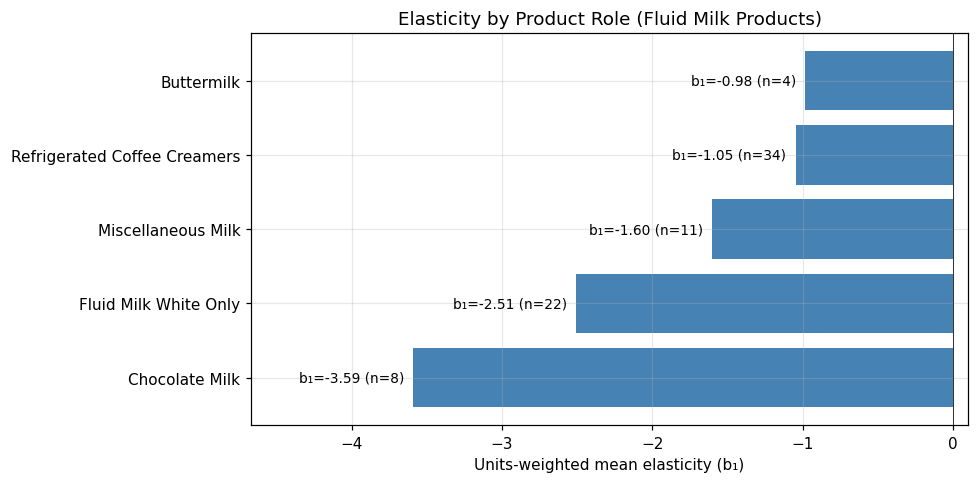

In [14]:
# Per-SKU elasticity, aggregated into comparable product roles
# (SUB_COMMODITY_DESC). Fit each SKU individually, keep quality-passing
# SKUs, then take a units-weighted mean within each role.
sku_week = (
    raw.groupby(["PRODUCT_ID", "SUB_COMMODITY_DESC", "WEEK_NO"])
    .agg(units=("QUANTITY", "sum"), revenue=("SALES_VALUE", "sum"))
    .reset_index()
)
sku_week["effective_price"] = (sku_week["revenue"] / sku_week["units"]).round(2)

role_rows = []
for (pid, sub), g in sku_week.groupby(["PRODUCT_ID", "SUB_COMMODITY_DESC"]):
    if not check_data_quality(g, CONFIG)["pass_all"]:
        continue
    try:
        r = fit_elasticity_two_pass(
            g["effective_price"].values, g["units"].values, CONFIG
        )
    except RuntimeError:
        continue
    # Drop economically nonsensical fits (positive or absurd magnitude)
    if not (-8.0 < r["b1"] < 0.0):
        continue
    role_rows.append({
        "product_role": sub.title(),
        "b1": r["b1"],
        "total_units": g["units"].sum(),
    })

sku_elast = pd.DataFrame(role_rows)

MIN_SKUS = 4  # only show roles with enough SKUs to be meaningful
role_elast = (
    sku_elast.groupby("product_role")
    .apply(
        lambda x: pd.Series({
            "n_sku": len(x),
            "elasticity": np.average(x["b1"], weights=x["total_units"]),
        }),
        include_groups=False,
    )
    .reset_index()
)
role_elast = (
    role_elast[role_elast["n_sku"] >= MIN_SKUS]
    .sort_values("elasticity")
    .reset_index(drop=True)
)
display(role_elast)

# Bar chart — elasticity by product role
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(role_elast["product_role"], role_elast["elasticity"],
        color="steelblue")
ax.set_xlabel("Units-weighted mean elasticity (b\u2081)")
ax.set_title("Elasticity by Product Role (Fluid Milk Products)")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(role_elast["elasticity"].min() * 1.30, 0.1)
for i, row in role_elast.iterrows():
    ax.text(row["elasticity"] - 0.06, i,
            f"b\u2081={row['elasticity']:.2f} (n={int(row['n_sku'])})",
            va="center", ha="right", fontsize=9)
fig.tight_layout()
savefig(fig, "product_role_elasticity.png")
plt.show()

## 8. From Elasticity to Margin Optimization

Elasticity tells you how volume responds to price.
The business question is: **which price maximizes contribution margin?**

$$
\text{Contribution Margin}(P) = (P - C) \times Q(P) = (P - C) \times b_0 \, P^{\,b_1}
$$

**Note on cost data:**  The Dunnhumby dataset does not include cost
information. We assume cost = 55 % of average selling price — a standard
retail gross margin for dairy products (~45 %).  In practice you would
substitute your actual cost-of-goods-sold. The optimization *direction*
is robust to moderate changes in the cost assumption; only the exact
optimal price shifts.

We restrict optimization to items with a **Usable** verdict and **elastic**
demand ($b_1 < -1$). Under constant elasticity the contribution-margin curve
has an interior maximum only when $|b_1| > 1$; for inelastic items margin
rises monotonically with price, so a bounded optimizer just returns the upper
bound — not a real recommendation.

In [15]:
def neg_contribution_margin(price, b0, b1, variable_cost):
    """Negative contribution margin (for minimization)."""
    quantity = b0 * price ** b1
    return -(price - variable_cost) * quantity


def optimize_margin(result, price_bounds=None):
    """Find the price that maximizes contribution margin."""
    vc = result["avg_cost"]
    if price_bounds is None:
        price_bounds = (vc * 1.05, result["avg_price"] * 3)
    opt = minimize_scalar(
        neg_contribution_margin,
        bounds=price_bounds,
        method="bounded",
        args=(result["b0"], result["b1"], vc),
    )
    opt_price = opt.x
    lo, hi = price_bounds
    if min(opt_price - lo, hi - opt_price) < 0.01 * (hi - lo):
        warnings.warn(
            f"optimize_margin: solution pinned at a price bound "
            f"(P={opt_price:.2f}); no interior margin optimum in range — "
            "do not use as a price recommendation."
        )
    opt_units = power_model(opt_price, result["b0"], result["b1"])
    return {
        "optimal_price": opt_price,
        "max_margin": -opt.fun,
        "optimal_units": opt_units,
        "variable_cost": vc,
    }

In [16]:
# Optimise margin for items with economically sensible (negative) elasticity
opt_results = {}
rows = []
for label, res in results.items():
    if res["verdict"] != "Usable":
        continue  # only optimize statistically usable fits
    if res["b1"] >= -1:
        # Inelastic: under constant elasticity, margin rises monotonically with
        # price (no interior optimum), so the optimizer would just pin to the
        # upper bound. Skip rather than emit a bogus "optimal price".
        print(f"  {label}: inelastic (|b1| <= 1) — no interior margin optimum; skipped.")
        continue
    opt = optimize_margin(res)
    opt_results[label] = opt
    cur_p = res["avg_price"]
    cur_u = power_model(cur_p, res["b0"], res["b1"])
    cur_margin = (cur_p - opt["variable_cost"]) * cur_u
    rows.append({
        "Item": label,
        "Current Price": cur_p,
        "Optimal Price": opt["optimal_price"],
        "Price Change": f"{(opt['optimal_price']/cur_p - 1):+.1%}",
        "Current Margin/wk": cur_margin,
        "Optimal Margin/wk": opt["max_margin"],
        "Margin Uplift": f"{(opt['max_margin']/cur_margin - 1):+.1%}" if cur_margin > 0 else "N/A",
    })

if rows:
    opt_df = pd.DataFrame(rows).set_index("Item")
    display(opt_df)
else:
    print("No items with Usable verdict and negative elasticity for margin optimization.")

,Current Price,Optimal Price,Price Change,Current Margin/wk,Optimal Margin/wk,Margin Uplift
Item,,,,,,
Chocolate Milk — Private #4,1.47,1.08,-26.1%,30.35,41.69,+37.4%
Fluid Milk White Only — Private #12,1.48,1.23,-17.3%,32.89,35.68,+8.5%
Fluid Milk White Only — Private #13,1.48,1.13,-23.6%,97.76,121.39,+24.2%
Fluid Milk White Only — Private #15,1.48,1.31,-11.3%,32.55,33.42,+2.7%
Fluid Milk White Only — Private #16,1.48,1.11,-24.9%,52.22,67.92,+30.1%


In [17]:
def plot_margin_curve(label, result, opt, ax=None):
    """Revenue and Contribution-Margin curves with current/optimal markers."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    vc = opt["variable_cost"]
    cur_p = result["avg_price"]
    grid = np.linspace(vc * 1.05, cur_p * 2.5, 300)
    q = power_model(grid, result["b0"], result["b1"])
    revenue = grid * q
    margin = (grid - vc) * q

    ax.plot(grid, revenue, label="Revenue", color="steelblue", linewidth=2)
    ax.plot(grid, margin, label="Contribution Margin", color="darkgreen", linewidth=2)

    # Current price marker
    ax.axvline(cur_p, color="grey", linestyle="--", linewidth=1,
               label=f"Current ${cur_p:.2f}")
    # Optimal price marker
    ax.axvline(opt["optimal_price"], color="red", linestyle="--", linewidth=1,
               label=f"Optimal ${opt['optimal_price']:.2f}")

    ax.set_xlabel("Price ($)")
    ax.set_ylabel("Weekly ($)")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    return ax

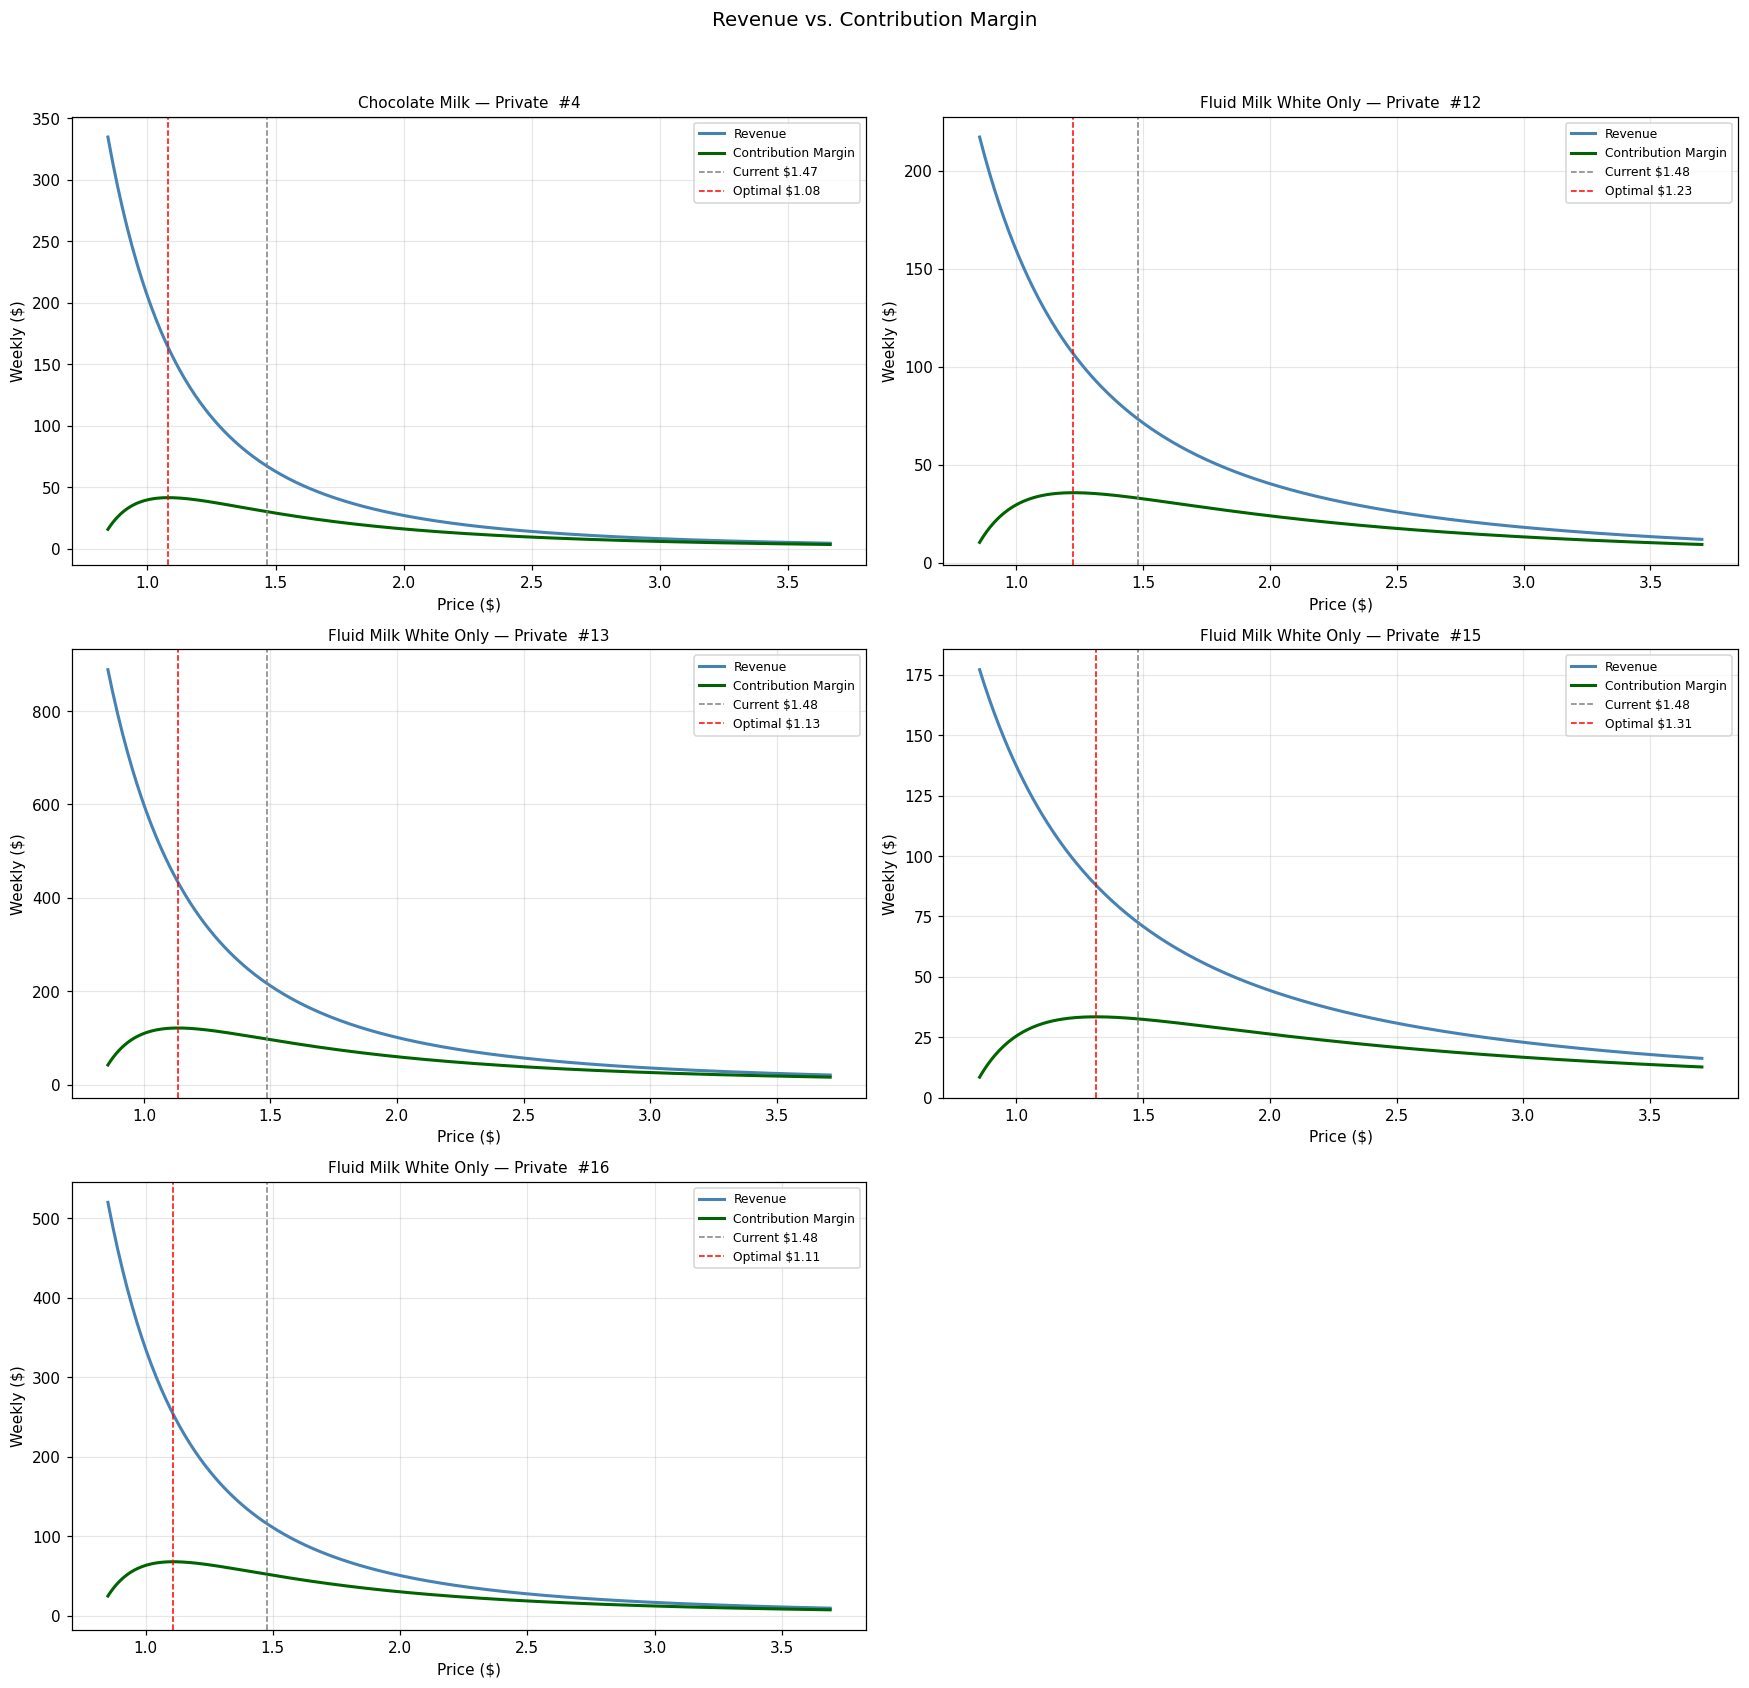

In [18]:
if opt_results:
    items_to_plot = list(opt_results.keys())
    n_plot = len(items_to_plot)
    if n_plot >= 2:
        ncols = 2
        nrows = (n_plot + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
        axes = axes.flatten()
        for i, label in enumerate(items_to_plot):
            plot_margin_curve(label, results[label], opt_results[label], ax=axes[i])
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        fig.suptitle("Revenue vs. Contribution Margin", fontsize=13, y=1.02)
        fig.tight_layout()
    elif n_plot == 1:
        label = items_to_plot[0]
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_margin_curve(label, results[label], opt_results[label], ax=ax)
        plt.tight_layout()
    savefig(fig, "margin_optimization_curves.png")
    plt.show()
else:
    print("No margin curves to plot (no Usable items with negative elasticity).")

## 9. Price-Sensitivity Table

A sensitivity table translates the model into the language stakeholders
understand: *"If I raise the price by 10 %, what happens to units, revenue,
and margin?"*  The table below shows six scenarios from −20 % to +30 %
relative to the current price.

In [19]:
def price_sensitivity_table(result, current_price, variable_cost,
                            pct_changes=(-0.20, -0.10, 0, 0.10, 0.20, 0.30)):
    """Build a what-if table at several price points."""
    rows = []
    for pct in pct_changes:
        p = current_price * (1 + pct)
        q = power_model(p, result["b0"], result["b1"])
        rev = p * q
        margin_unit = p - variable_cost
        total_margin = margin_unit * q
        rows.append({
            "Price Change": f"{pct:+.0%}",
            "Price ($)": round(p, 2),
            "Units/wk": round(q, 0),
            "Revenue/wk ($)": round(rev, 0),
            "Margin/Unit ($)": round(margin_unit, 2),
            "Total Margin/wk ($)": round(total_margin, 0),
        })
    return pd.DataFrame(rows)


if opt_results:
    example_label = list(opt_results.keys())[0]
    example_res = results[example_label]
    example_opt = opt_results[example_label]

    print(f"Sensitivity analysis: {example_label}")
    print(f"  Current price: ${example_res['avg_price']:.2f}  |  "
          f"Assumed cost: ${example_opt['variable_cost']:.2f}  |  "
          f"Elasticity: {example_res['b1']:.2f}")
    print()
    display(price_sensitivity_table(
        example_res,
        example_res["avg_price"],
        example_opt["variable_cost"],
    ))
else:
    print("No Usable items \u2014 sensitivity table skipped.")

Sensitivity analysis: Chocolate Milk — Private  #4
  Current price: $1.47  |  Assumed cost: $0.81  |  Elasticity: -3.92



,Price Change,Price ($),Units/wk,Revenue/wk ($),Margin/Unit ($),Total Margin/wk ($)
0,-20%,1.17,110.00,129.00,0.37,40.00
1,-10%,1.32,70.00,92.00,0.51,36.00
2,+0%,1.47,46.00,67.00,0.66,30.00
3,+10%,1.61,32.00,51.00,0.81,26.00
4,+20%,1.76,23.00,40.00,0.95,21.00
5,+30%,1.90,16.00,31.00,1.10,18.00


## 10. Pitfalls

**Endogeneity.**
Prices are not set randomly.  If the retailer raises prices when demand
is already high (holidays, seasonal peaks), the estimated elasticity is
biased toward zero — demand looks *less* elastic than it really is.
Solutions include instrumental variables, randomized price experiments,
and quasi-experimental designs.

**Reference-price effect.**
Customers remember the previous price.  Elasticity for a price *increase*
is typically larger (more volume loss) than for an equivalent *decrease*
(less volume gain).  A single elasticity number is an approximation.

**Short-run vs. long-run.**
Scanner data captures short-run elasticity.  Long-run elasticity can be
2–3× higher as customers find alternatives and form new habits.

**Competitor reaction.**
Your price cut only works if competitors do not follow.  In concentrated
categories they usually do — everyone sells the same volume at lower
margins.

**Assumed costs.**
This notebook uses an assumed cost ratio (55 % of average price) because
the Dunnhumby dataset does not include cost data.  Margin optimization
results should be recalculated with actual COGS before making pricing
decisions.

## Key Takeaways

1. **Effective price** = Revenue / Units — accounts for promotions and mixed pricing.
2. Run **data-quality checks** (distinct prices, mode share, observation count, range) *before* fitting.
3. The **power-law model** $Q = b_0 P^{b_1}$ gives a practical constant-elasticity estimate; **two-pass estimation** removes promotional outliers.
4. Scanner data with many price points (40–60 per product) produces **richer elasticity curves** and higher R² than state-controlled pricing data.
5. **Be explicit about the objective — and when reliable cost data exists, optimize contribution margin.** The margin-maximizing price and the revenue-maximizing price are different.
6. Elasticity varies by **product role** (sub-commodity within a category). A single price may leave money on the table.
7. Watch for **endogeneity**, **reference-price effects**, and **short-run vs. long-run** differences before acting on the numbers.
8. When cost data is unavailable, an **assumed cost ratio** lets you demonstrate the optimization framework — but always substitute real COGS before making decisions.